# LLM Benchmarks Analysis (2024 – 2026)

**Team 2**

---

## Imports & Setup
Run this cell first before anything else.

**Imports & configuration** — Brings in `pandas` for data manipulation, `numpy` for numerical operations, `matplotlib.pyplot` for plotting, and `seaborn` for styled charts. Sets a `whitegrid` theme with `font_scale=1.1` and bumps figure DPI to 120 for crisp output.

In [2]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn theme and plot resolution for better visual quality
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

## 1. Data Cleaning & Preparation
Load the raw CSV, fix column types, strip whitespace, tag models by size and provider, and audit missing values.

**Load dataset** — Reads `llm_price_performance_tracker.csv` into a DataFrame `df`. Prints the shape `(rows, cols)` and full column list so we can confirm the file loaded correctly before touching any data.

In [3]:
print('='*50)
df = pd.read_csv("llm_price_performance_tracker.csv")
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print('='*50)

Shape: (453, 34)
Columns: ['model_name', 'model_slug', 'provider', 'provider_slug', 'aa_id', 'aa_intelligence_index', 'aa_coding_index', 'aa_math_index', 'composite_benchmark', 'mmlu_pro', 'gpqa_diamond', 'humanitys_last_exam', 'livecodebench', 'scicode', 'math_500', 'aime_2025', 'input_cost_usd_per_1m', 'output_cost_usd_per_1m', 'blended_cost_usd_per_1m', 'pricing_tier', 'output_tokens_per_second', 'time_to_first_token_s', 'time_to_first_answer_s', 'chatbot_arena_elo', 'arena_elo_ci95', 'arena_votes', 'parameter_count', 'release_year', 'is_open_source', 'intelligence_per_dollar', 'price_performance_ratio', 'elo_benchmark_blend', 'speed_per_dollar', 'scrape_date']


**Strip whitespace** — Selects every `object`-dtype column (text columns) and calls `.str.strip()` on each. Verifies the result with a regex check on `model_name`; prints a success message if no leading/trailing spaces remain.

In [4]:
print('='*50)
# get columns that contain text
text_cols = df.select_dtypes(include='object').columns

# removing spaces
for col in text_cols:
    df[col] = df[col].str.strip()

# check if been done successfully
if ((df['model_name'].str.contains('^\\s|\\s$').sum())==0):
    print ('Space removing done')
    
print('='*50)

Space removing done


**Fix column types** — Casts `arena_votes` and `release_year` to pandas `Int64` (nullable integer, handles NaN safely). Converts `scrape_date` from a plain string to a proper `datetime64` type so date arithmetic works correctly later.

In [5]:
# make all numeric columns integers
df['arena_votes'] = df['arena_votes'].astype('Int64')
df['release_year'] = df['release_year'].astype('Int64')

# checking
print('release_year type:',df['release_year'].dtype)
print('arena_votes type:',df['arena_votes'].dtype)

print('='*50)
print(df['scrape_date'].head())
print(df['scrape_date'].dtype)
print('='*50)

df["scrape_date"] = pd.to_datetime(df["scrape_date"])
print(df['scrape_date'].dtype)
print('='*50)

release_year type: Int64
arena_votes type: Int64
0    3/31/2026
1    3/31/2026
2    3/31/2026
3    3/31/2026
4    3/31/2026
Name: scrape_date, dtype: object
object
datetime64[ns]


**Missing value audit (counts)** — Iterates over every column, counts `NaN` values, and prints only the columns that actually have missing data. Gives a quick picture of where gaps exist before deciding how to handle them.

In [6]:
# missing values for each column
values = [df[col].isnull().sum() for col in df.columns]
labels = [col for col in df.columns]
missing = pd.Series(values, index=labels)

print('='*40)
print(missing[missing > 0])
print('='*40)

aa_intelligence_index         7
aa_coding_index              97
aa_math_index               185
composite_benchmark          20
mmlu_pro                    109
gpqa_diamond                 29
humanitys_last_exam          33
livecodebench               111
scicode                      35
math_500                    252
aime_2025                   259
input_cost_usd_per_1m       138
output_cost_usd_per_1m      138
blended_cost_usd_per_1m     138
output_tokens_per_second    174
time_to_first_token_s       174
time_to_first_answer_s      174
chatbot_arena_elo           407
arena_elo_ci95              407
arena_votes                 407
parameter_count             167
release_year                161
intelligence_per_dollar     156
price_performance_ratio     158
elo_benchmark_blend         407
speed_per_dollar            190
dtype: int64


**Parameter count statistics** — Calls `.describe()` on `parameter_count` to get count, mean, std, min, max, and the 25th / 50th / 75th percentiles. This informs the Small / Medium / Large thresholds used in the next step.

In [7]:
# important to find the 25th, 50th, and 75th percentiles
df["parameter_count"].describe()

count     286.000000
mean      168.665734
std       234.257631
min         0.600000
25%         9.250000
50%        49.000000
75%       235.000000
max      1200.000000
Name: parameter_count, dtype: float64

**Feature engineering** — Creates two new columns: `parameter_size` (`Small` < 10 B, `Medium` < 100 B, `Large` ≥ 100 B) using `np.select`, and `source_label` which mirrors the `provider` column for use as a readable grouping label in charts.

In [8]:
print('='*50)

# categorize models by parameter size 
conditions = [
    df["parameter_count"] < 10,
    df["parameter_count"] < 100,
    df["parameter_count"] >= 100
]

choices = ["Small", "Medium", "Large"]
df["parameter_size"] = np.select(conditions, choices, default="Unknown")

providers = df["provider"].unique().tolist()
conditions = [df["provider"] == prov for prov in providers]
df["source_label"] = np.select(conditions, providers, default="Other")

print(df["source_label"].value_counts())
print('='*50)

source_label
Alibaba                                  71
OpenAI                                   59
Google                                   43
Mistral                                  31
Anthropic                                28
DeepSeek                                 25
Meta                                     16
NVIDIA                                   16
Z AI                                     15
xAI                                      14
Amazon                                   13
Allen Institute for AI                   10
Liquid AI                                 8
AI21 Labs                                 7
IBM                                       7
Nous Research                             7
Upstage                                   6
MiniMax                                   6
LG AI Research                            6
Kimi                                      6
Perplexity                                5
Xiaomi                                    5
InclusionAI        

**DataFrame info summary** — Calls `df.info()` to print column names, non-null counts, dtype per column, and total memory usage. A quick sanity check that all type conversions from the previous cells took effect.

In [9]:
print('='*60)
# general summary
df.info()
print('='*60)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   model_name                453 non-null    object        
 1   model_slug                453 non-null    object        
 2   provider                  453 non-null    object        
 3   provider_slug             453 non-null    object        
 4   aa_id                     453 non-null    object        
 5   aa_intelligence_index     446 non-null    float64       
 6   aa_coding_index           356 non-null    float64       
 7   aa_math_index             268 non-null    float64       
 8   composite_benchmark       433 non-null    float64       
 9   mmlu_pro                  344 non-null    float64       
 10  gpqa_diamond              424 non-null    float64       
 11  humanitys_last_exam       420 non-null    float64       
 12  livecodebench         

**Missing value percentages** — Computes `(null count / total rows) × 100` for every column, keeps only columns above 0 %, and sorts descending. Useful for deciding which columns are safe to use in analysis vs. which need imputation or dropping.

In [10]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(missing_pct)


elo_benchmark_blend         89.85
arena_votes                 89.85
arena_elo_ci95              89.85
chatbot_arena_elo           89.85
aime_2025                   57.17
math_500                    55.63
speed_per_dollar            41.94
aa_math_index               40.84
time_to_first_token_s       38.41
time_to_first_answer_s      38.41
output_tokens_per_second    38.41
parameter_count             36.87
release_year                35.54
price_performance_ratio     34.88
intelligence_per_dollar     34.44
blended_cost_usd_per_1m     30.46
output_cost_usd_per_1m      30.46
input_cost_usd_per_1m       30.46
livecodebench               24.50
mmlu_pro                    24.06
aa_coding_index             21.41
scicode                      7.73
humanitys_last_exam          7.28
gpqa_diamond                 6.40
composite_benchmark          4.42
aa_intelligence_index        1.55
dtype: float64


## 2. Who Are the Players?
Four charts that map the competitive landscape: provider model counts, parameter distribution, open vs. closed source split, and releases per year.

**Models per provider** — Uses `value_counts()` to count how many models each provider contributed to the dataset. Plots the result as a bar chart so the dominant players are immediately visible.

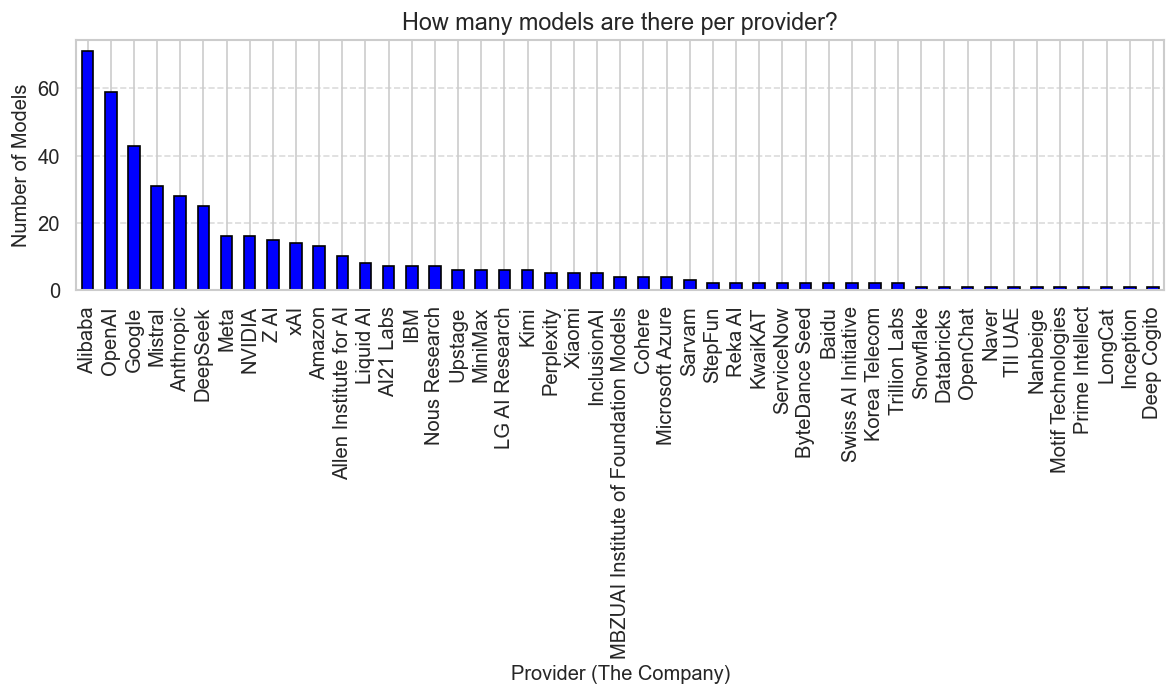

In [41]:
provider_counts = df['provider'].value_counts()
plt.figure(figsize=(10, 6))
provider_counts.plot(kind='bar', color='blue', edgecolor='black')
plt.title('How many models are there per provider?', fontsize=14)
plt.xlabel('Provider (The Company)', fontsize=12)
plt.ylabel('Number of Models', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Parameter count distribution** — Plots a histogram with 10 bins to show how model sizes cluster across the dataset. Reveals whether most models are small/mid-range or whether large frontier models dominate. Saves to `parameters_histogram.png`.

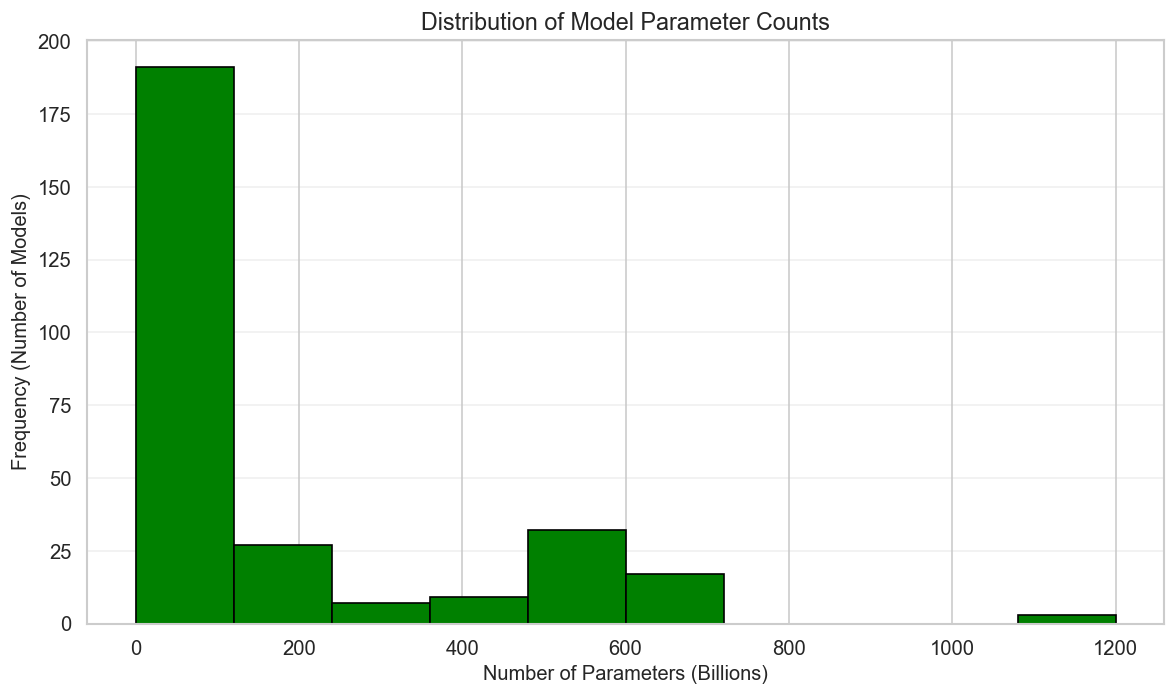

In [40]:
plt.figure(figsize=(10, 6))
plt.hist(df['parameter_count'], bins=10, color='green', edgecolor='black')
plt.title('Distribution of Model Parameter Counts', fontsize=14)
plt.xlabel('Number of Parameters (Billions)', fontsize=12)
plt.ylabel('Frequency (Number of Models)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('parameters_histogram.png')
plt.show()

**Open-source vs. closed-source split** — Counts models by `is_open_source`, relabels `True/False` to readable names, and draws a pie chart with percentage labels. The `explode` and `shadow` settings make the slices easier to distinguish.

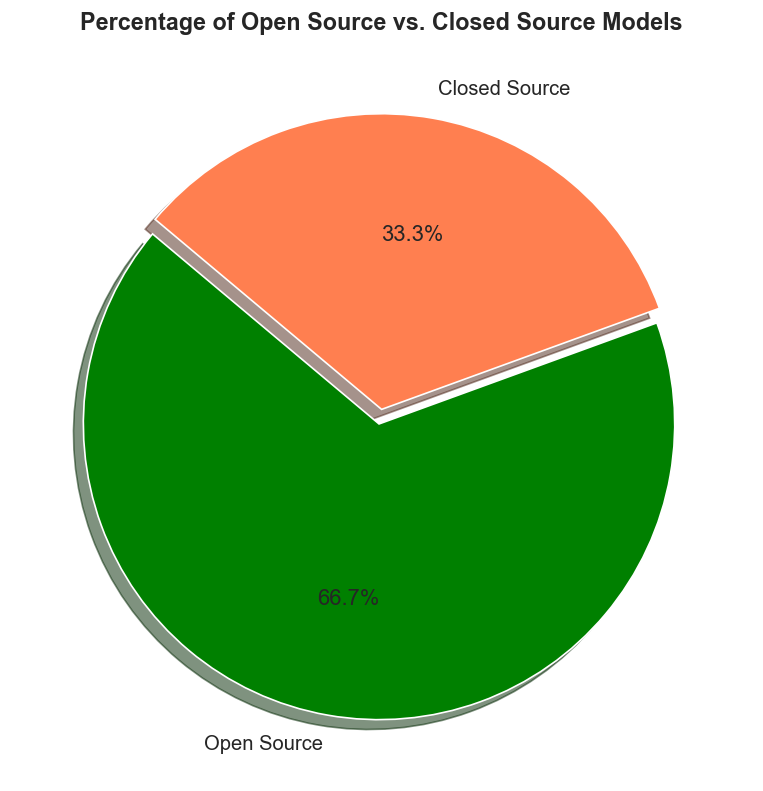

In [39]:
source_counts = df['is_open_source'].value_counts()
source_counts.index = ['Open Source' if x == True else 'Closed Source' for x in source_counts.index]
plt.figure(figsize=(8, 8))
colors = ['green', 'coral']
plt.pie(source_counts, 
        labels=source_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=(0.05, 0), 
        shadow=True)
plt.title('Percentage of Open Source vs. Closed Source Models', fontsize=14, fontweight='bold')
plt.show()

**Releases per year** — Groups models by `release_year` and counts entries per year. The bar chart shows how the pace of new model releases has changed over the 2024–2026 period covered by the dataset.

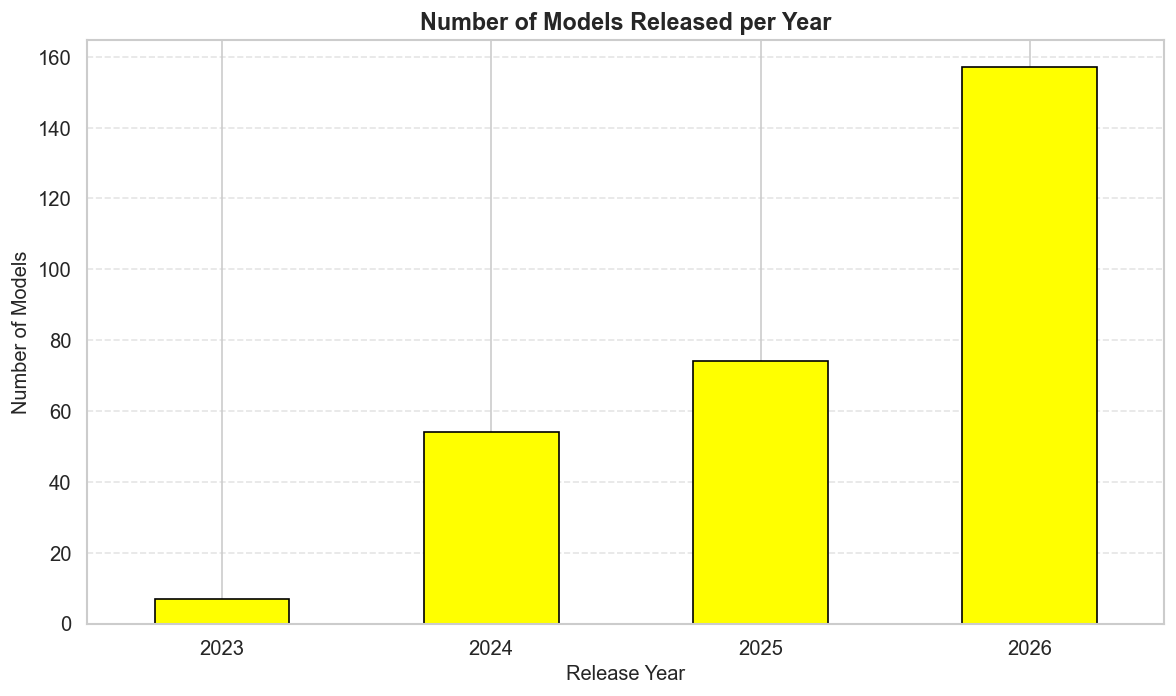

In [38]:
year_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
year_counts.plot(kind='bar', color='yellow', edgecolor='black')
plt.title('Number of Models Released per Year', fontsize=14, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Models', fontsize=12)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Who Performs Best?
Rank models on composite benchmark, Arena ELO, coding, and math scores; then explore how these metrics correlate with each other.

**Top 10 by composite benchmark** — Sorts `df` on `composite_benchmark` descending and keeps the top 10. Also flags a handful of anomalous entries (models with mismatched provider labels) before plotting a horizontal bar chart.

                      model_name  composite_benchmark
333                      R1 1776                95.40
155                   o1-preview                92.40
144          Sonar Reasoning Pro                87.35
43                        o3-pro                84.50
223              Sonar Reasoning                77.13
323      DeepSeek-V2.5 (Dec '24)                76.30
22                  GPT-5 (high)                74.51
354            DeepSeek-Coder-V2                74.30
39                        Grok 4                74.16
12   Gemini 3 Pro Preview (high)                73.12
Model Name                     Provider
------------------     ----------------
R1 1776                      Perplexity
o1-preview                       OpenAI
Sonar Reasoning Pro          Perplexity
o3-prompt                    Perplexity
Sonar Reasoning                  OpenAI
dtype: object


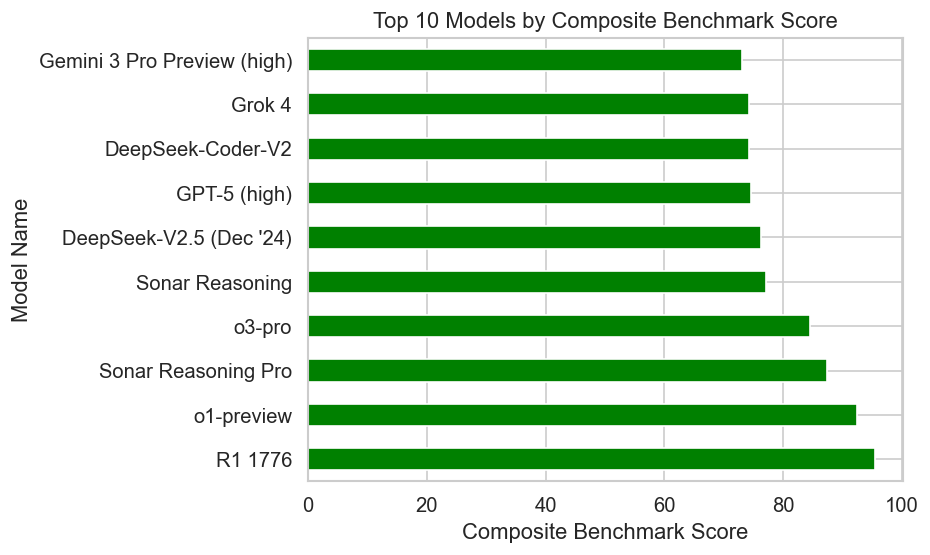

In [15]:
# sort and compare top 10 models by composite benchmark score
top_models = df.sort_values(by="composite_benchmark", ascending=False).head(10)
top_models = top_models[["model_name", "composite_benchmark"]]
print(top_models)

print("=" * 50)

strange_models = pd.Series(
    {
        "Model Name": "Provider",
        "------------------": "----------------",
        "R1 1776": "Perplexity",
        "o1-preview": "OpenAI",
        "Sonar Reasoning Pro": "Perplexity",
        "o3-prompt": "Perplexity",
        "Sonar Reasoning": "OpenAI",
    }
)
print(strange_models)

print("=" * 50)

top_models.plot(x="model_name", y="composite_benchmark", kind="barh", legend=False, color="green")
plt.title("Top 10 Models by Composite Benchmark Score")
plt.xlabel("Composite Benchmark Score")
plt.ylabel("Model Name")
plt.show()

**Top 10 by Chatbot Arena ELO** — Sorts on `chatbot_arena_elo` (a human-preference ranking from pairwise comparisons) and plots the top 10 as a horizontal bar chart. Lets us compare human judgement with the automated benchmark ranking.

                                         model_name  chatbot_arena_elo
18     Claude Opus 4.6 (Non-reasoning, High Effort)             1500.0
1                            Gemini 3.1 Pro Preview             1493.0
12                      Gemini 3 Pro Preview (high)             1486.0
39                                           Grok 4             1483.0
11                  Grok 4.20 Beta 0309 (Reasoning)             1483.0
72           Gemini 3 Flash Preview (Non-reasoning)             1474.0
28                  Claude Opus 4.5 (Non-reasoning)             1474.0
0                                   GPT-5.4 (xhigh)             1466.0
24   Claude Sonnet 4.6 (Non-reasoning, High Effort)             1463.0
157                   Grok 4.1 Fast (Non-reasoning)             1461.0


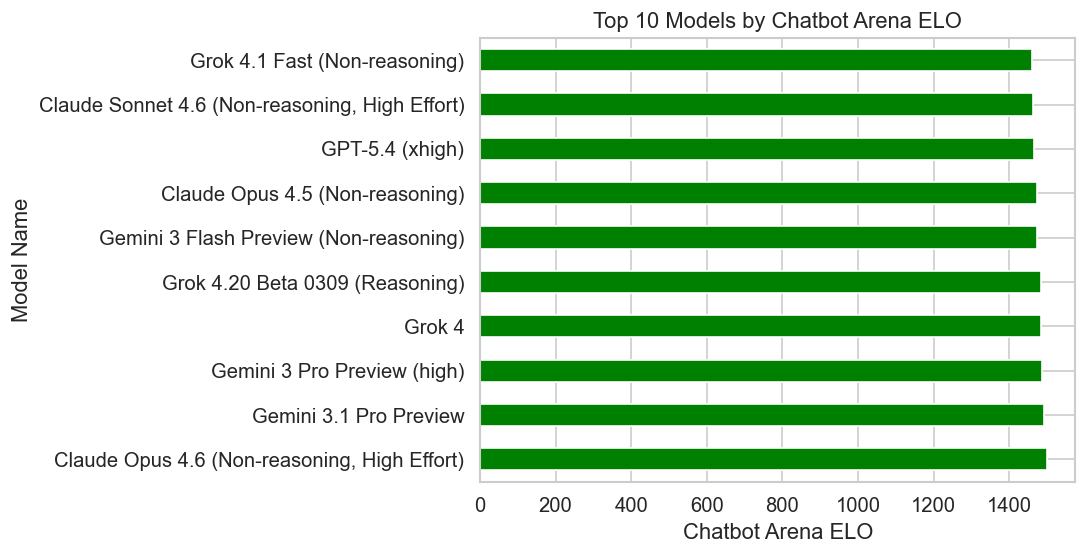

In [16]:
# compare top 10 models by chatbot arena score
top_chatbot_arena_models = df.sort_values(by='chatbot_arena_elo', ascending=False).head(10)
top_chatbot_arena_models = top_chatbot_arena_models[['model_name', 'chatbot_arena_elo']]
print(top_chatbot_arena_models)

print('='*50)

top_chatbot_arena_models.plot(x='model_name', y='chatbot_arena_elo', kind='barh', legend=False , color='green')
plt.title('Top 10 Models by Chatbot Arena ELO')
plt.xlabel('Chatbot Arena ELO')
plt.ylabel('Model Name')
plt.show()

**ELO vs. composite scatter** — Plots every model as a point with Arena ELO on the x-axis and composite benchmark on the y-axis. Points clustering near a diagonal suggest the two metrics agree; outliers reveal models that humans rate very differently from benchmarks.

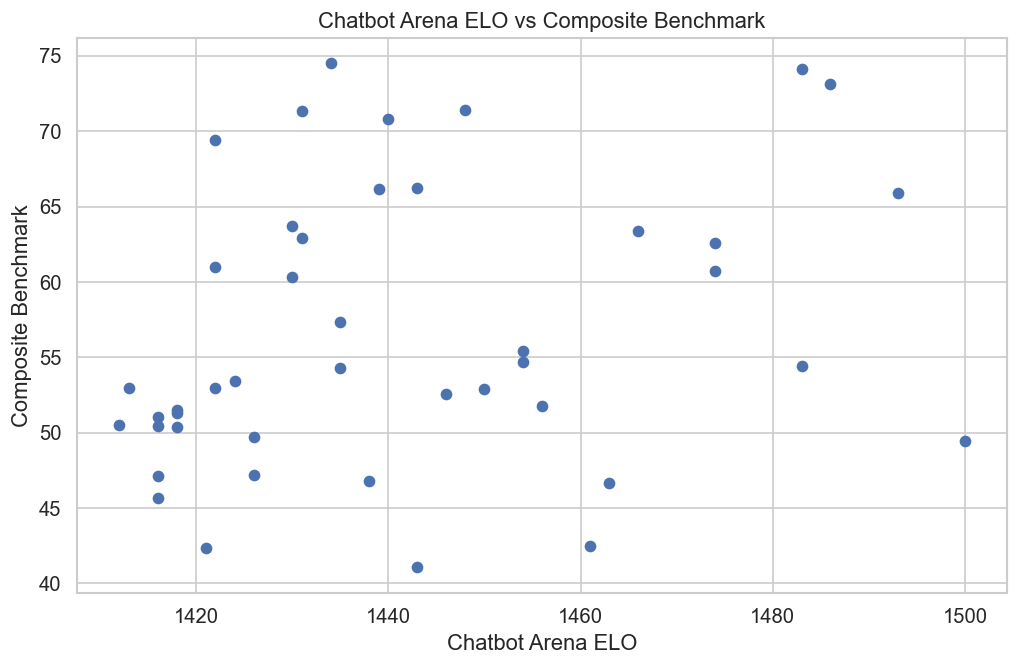

In [17]:
# scatter plot to see the relationship between chatbot arena elo and composite benchmark score
plt.figure(figsize=(10, 6))
plt.scatter(x = df['chatbot_arena_elo'], y = df['composite_benchmark'])
plt.title('Chatbot Arena ELO vs Composite Benchmark')
plt.xlabel('Chatbot Arena ELO')
plt.ylabel('Composite Benchmark')
plt.show()

**Top 10 by coding score** — Sorts on `aa_coding_index` and plots the top 10. The AA Coding Index measures performance on real-world programming tasks; comparing this ranking to the composite ranking shows which models specialise in code.

                                            model_name  aa_coding_index
0                                      GPT-5.4 (xhigh)             57.3
1                               Gemini 3.1 Pro Preview             55.5
2                                GPT-5.3 Codex (xhigh)             53.1
13                                GPT-5.4 mini (xhigh)             51.5
4    Claude Sonnet 4.6 (Adaptive Reasoning, Max Eff...             50.9
5                                      GPT-5.2 (xhigh)             48.7
3     Claude Opus 4.6 (Adaptive Reasoning, Max Effort)             48.1
7                          Claude Opus 4.5 (Reasoning)             47.8
18        Claude Opus 4.6 (Non-reasoning, High Effort)             47.6
101                   Gemini 2.5 Pro Preview (Mar' 25)             46.7


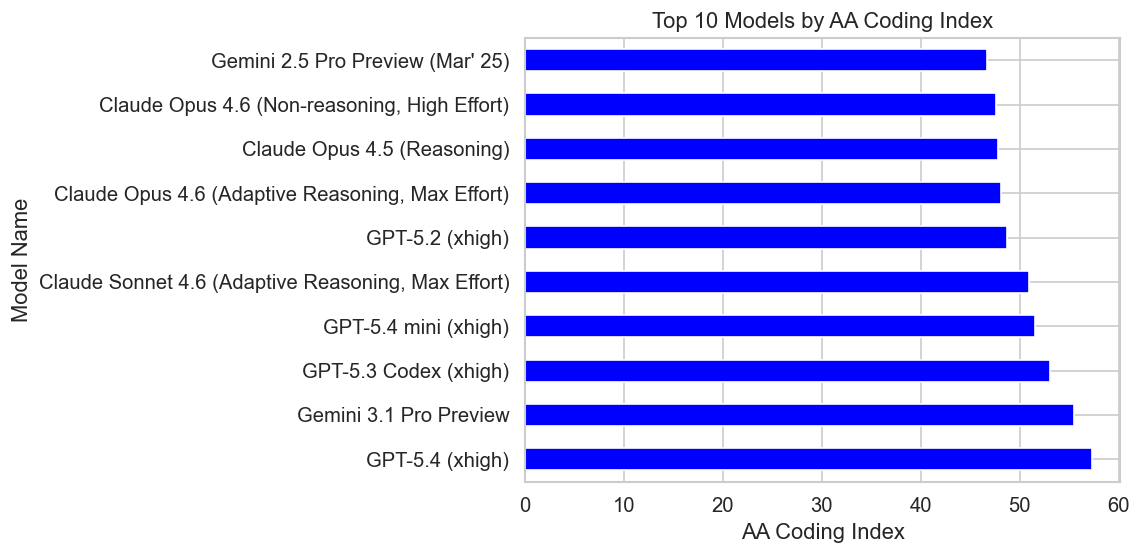

In [18]:
# compare top 10 models by aa coding index
top_coding_models = df.sort_values(by='aa_coding_index', ascending=False).head(10)
top_coding_models = top_coding_models[['model_name', 'aa_coding_index']]
print(top_coding_models)

print('='*50)

top_coding_models.plot(x='model_name', y='aa_coding_index', kind='barh', legend=False , color='blue')
plt.title('Top 10 Models by AA Coding Index')
plt.xlabel('AA Coding Index')
plt.ylabel('Model Name')
plt.show()

**Top 10 by math score** — Sorts on `aa_math_index` and plots the top 10. The AA Math Index covers competition-style and applied maths problems; a model leading here but not in coding highlights task-specific strengths.

                             model_name  aa_math_index
5                       GPT-5.2 (xhigh)           99.0
21                   GPT-5 Codex (high)           98.7
19   Gemini 3 Flash Preview (Reasoning)           97.0
17                     GPT-5.2 (medium)           96.7
108              DeepSeek V3.2 Speciale           96.7
49            MiMo-V2-Flash (Reasoning)           96.3
12          Gemini 3 Pro Preview (high)           95.7
27                 GPT-5.1 Codex (high)           95.7
32                  GLM-4.7 (Reasoning)           95.0
42                     Kimi K2 Thinking           94.7


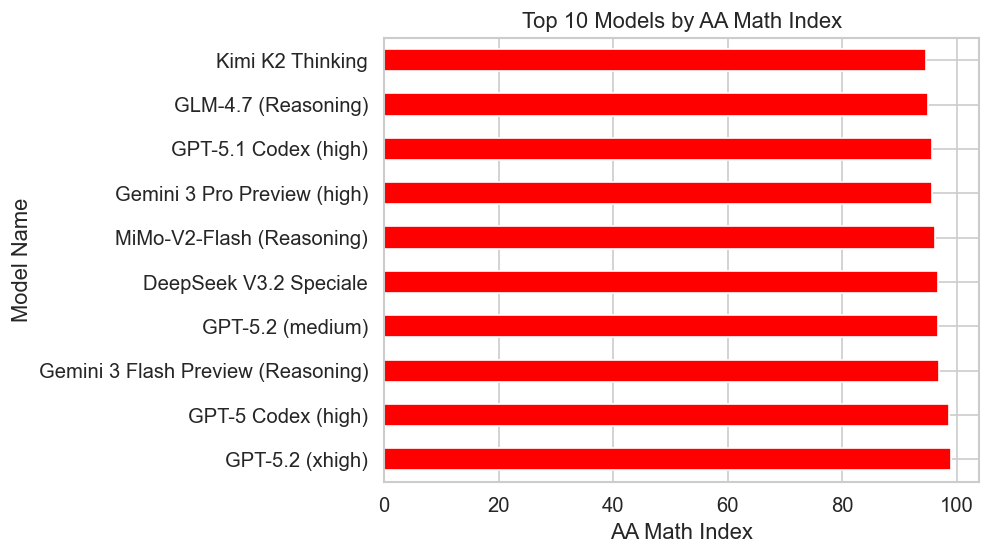

In [19]:
# compare top 10 models by aa math index
top_math_models = df.sort_values(by='aa_math_index', ascending=False).head(10)
top_math_models = top_math_models[['model_name', 'aa_math_index']]
print(top_math_models)

print('='*50)

top_math_models.plot(x='model_name', y='aa_math_index', kind='barh', legend=False , color='red')
plt.title('Top 10 Models by AA Math Index')
plt.xlabel('AA Math Index')
plt.ylabel('Model Name')
plt.show()

**Correlation heatmap** — Computes a 5×5 correlation matrix across `composite_benchmark`, `chatbot_arena_elo`, `aa_math_index`, `aa_intelligence_index`, and `aa_coding_index`. Annotated values and a diverging colormap make strong/weak correlations immediately readable.

Text(0.5, 1.0, 'Correlation Matrix of Key Performance Metrics')

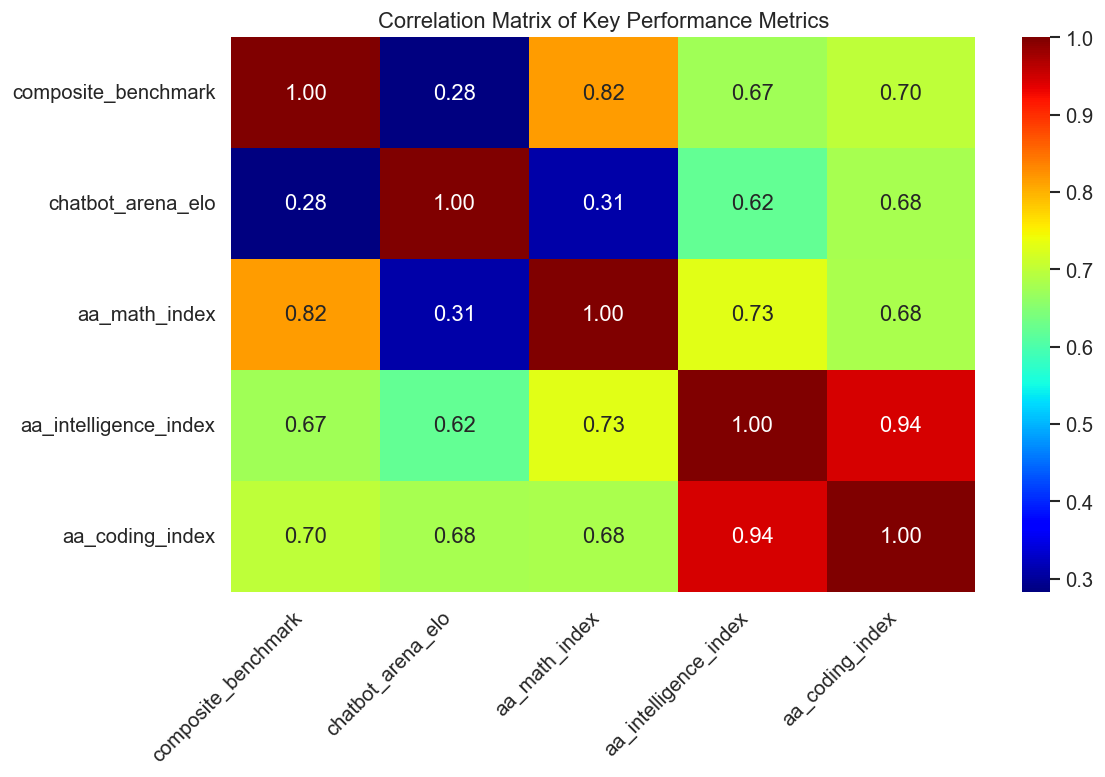

In [20]:
# correlation matrix to see the relationship between the different performance metrics with heatmap to visualize the correlation
plt.figure(figsize=(10, 6))
columns = ['composite_benchmark', 'chatbot_arena_elo', 'aa_math_index', 'aa_intelligence_index', 'aa_coding_index']
corr = df[columns].corr()
sns.heatmap(corr, annot=True, cmap='jet', fmt='.2f')
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Matrix of Key Performance Metrics')

**Pairplot** — Draws a grid of scatter plots (off-diagonal) and KDE distributions (diagonal) for all five performance metrics. Reveals non-linear relationships and clusters that a single correlation number would miss.

Text(0.5, 1.02, 'Pairwise Relationships Between Key Performance Metrics')

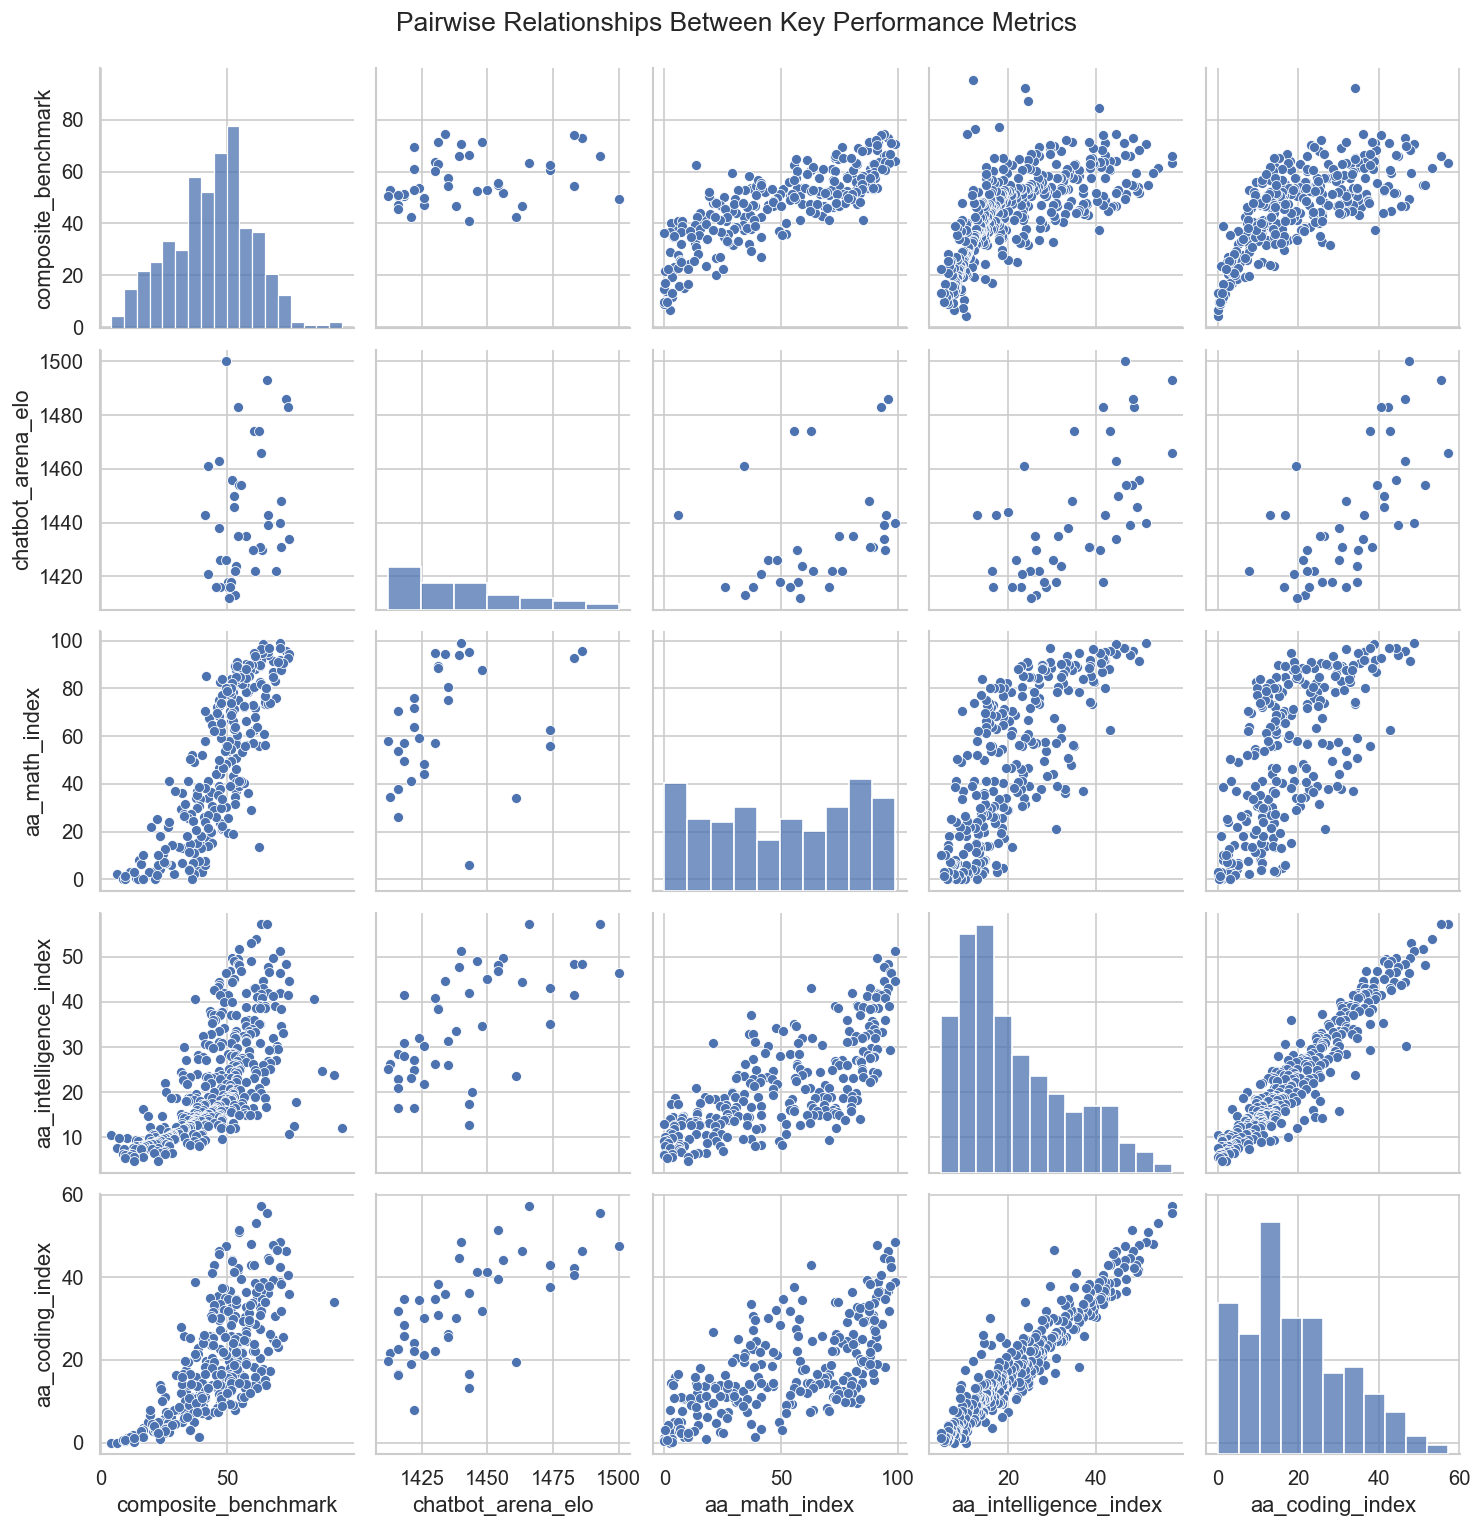

In [21]:
# pairplot to see the relationship between the different performance metrics
sns.pairplot(df[columns])
plt.suptitle('Pairwise Relationships Between Key Performance Metrics', y=1.02)

## 4. Who Is Cheapest and Fastest?
Identify the 5 cheapest and 5 fastest models, then compare average cost and speed across pricing tiers.

**Top 5 cheapest** — Uses `nsmallest(5, 'blended_cost_usd_per_1m')` to find the most affordable models. Plots them as a line-marker chart (instead of a bar) to emphasise the cost gaps between adjacent models.

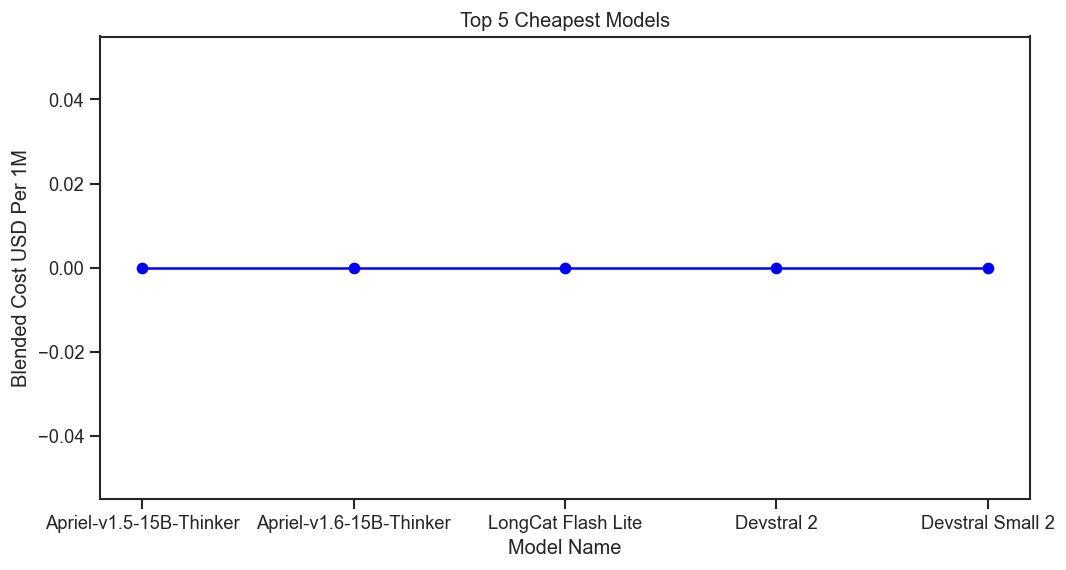

In [22]:
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [10, 5]

top_5_cheapest = df.nsmallest(5, 'blended_cost_usd_per_1m')

plt.figure()

plt.plot(
    top_5_cheapest['model_name'],
    top_5_cheapest['blended_cost_usd_per_1m'],
    marker='o',
    linestyle='-',
    color='blue'
)

plt.title('Top 5 Cheapest Models')
plt.xlabel('Model Name')
plt.ylabel('Blended Cost USD Per 1M')
plt.show()

**Top 5 fastest** — Sorts on `output_tokens_per_second` descending and keeps the top 5. A seaborn barplot with the `deep` palette makes differences in throughput easy to compare at a glance.

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_22804\890709812.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


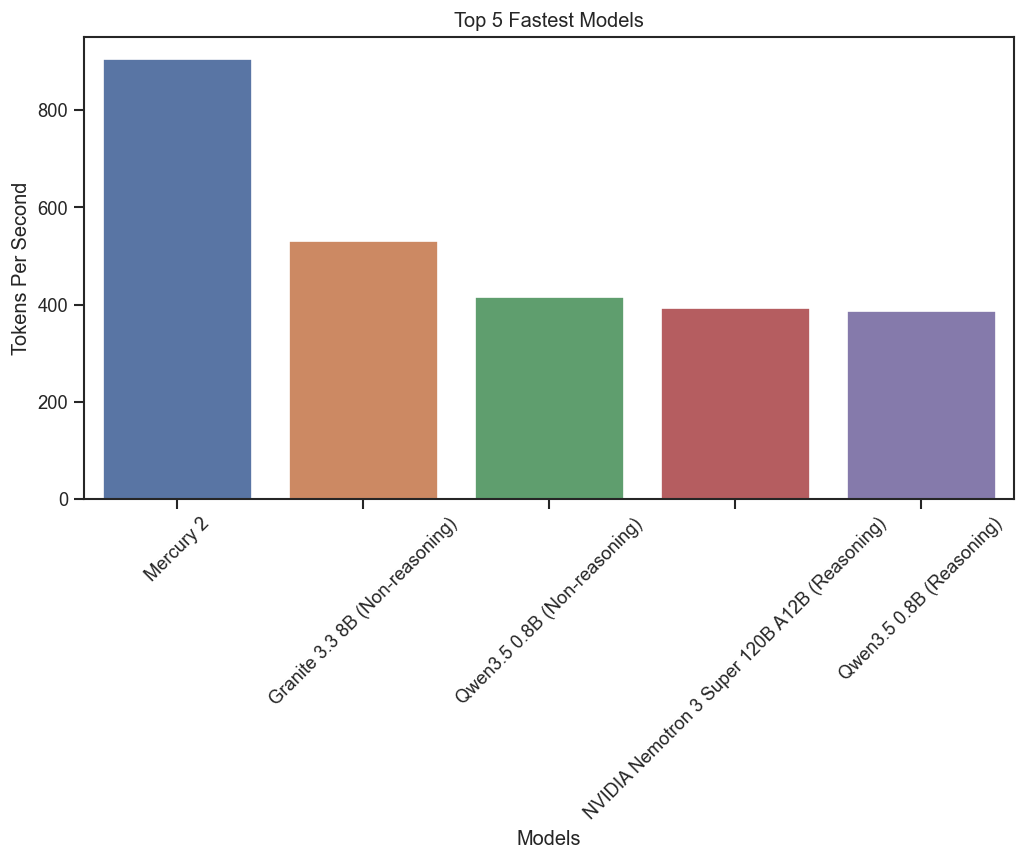

In [23]:
top_5_fastest = df.sort_values(
    "output_tokens_per_second",
    ascending=False
    ).head(5)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_5_fastest,
    x="model_name",
    y="output_tokens_per_second",
    palette="deep"
)

plt.title("Top 5 Fastest Models")
plt.xlabel("Models")
plt.ylabel("Tokens Per Second")
plt.xticks(rotation=45)
plt.show()

**Cost vs. speed by pricing tier** — Groups the full dataset by `pricing_tier`, computes average `blended_cost_usd_per_1m` and average `output_tokens_per_second` per tier, and plots both columns side by side to reveal the trade-off between price and speed.

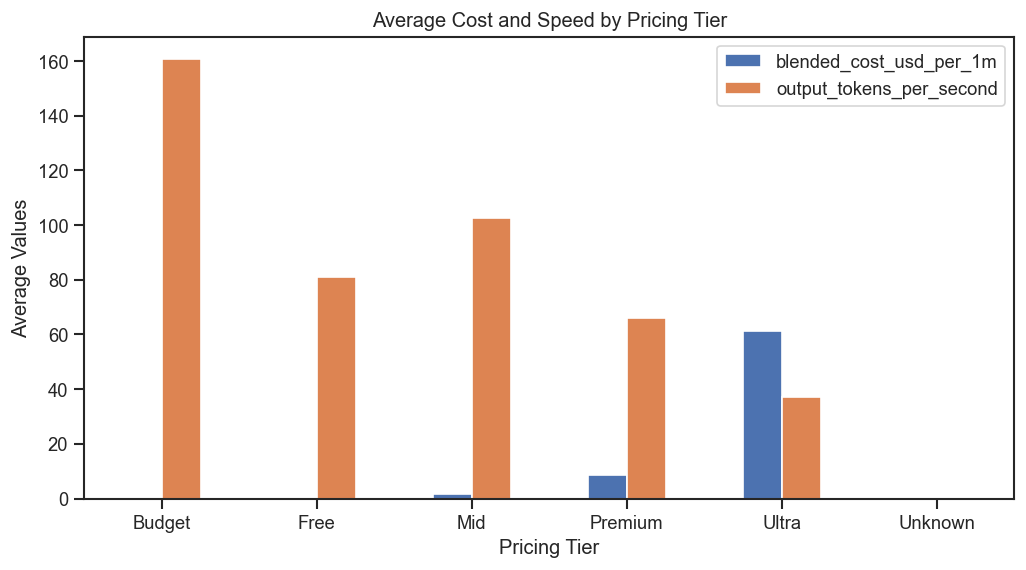

In [24]:
grouped = df.groupby("pricing_tier")[
    ["blended_cost_usd_per_1m", "output_tokens_per_second"]
].mean()

grouped.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Cost and Speed by Pricing Tier")
plt.xlabel("Pricing Tier")
plt.ylabel("Average Values")
plt.xticks(rotation=0)
plt.show()

## 5. Who Offers the Best Value for Money?
Correlate price with performance, compute an `intelligence_per_dollar` metric, and compare open-source vs. closed-source value.

**Section 5 setup** — Creates an output directory `section5_outputs/`, selects the four columns needed for value analysis, converts cost and benchmark to numeric, and drops rows where either is missing or cost is zero (division by zero would corrupt the metric).

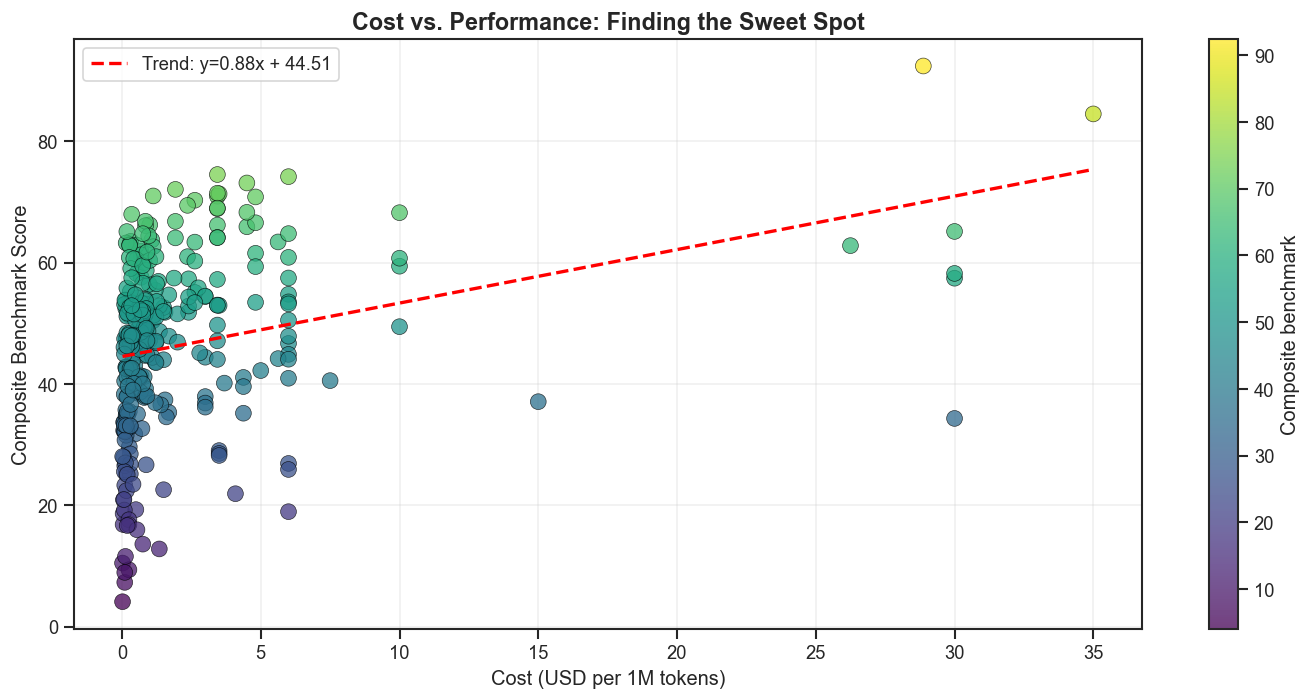

Correlation between cost and performance: 0.288
Weak correlation: cost is not a strong predictor of performance.


In [25]:
from pathlib import Path
OUTPUT_DIR = Path('section5_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
required_cols = [
    'model_name',
    'blended_cost_usd_per_1m',
    'composite_benchmark',
    'is_open_source',
]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

# Clean only the rows used in Section 5, keeping the original dataframe available.
value_df = df[required_cols].copy()
value_df['blended_cost_usd_per_1m'] = pd.to_numeric(
    value_df['blended_cost_usd_per_1m'], errors='coerce'
)
value_df['composite_benchmark'] = pd.to_numeric(
    value_df['composite_benchmark'], errors='coerce'
)
value_df = value_df.dropna(subset=['blended_cost_usd_per_1m', 'composite_benchmark'])

# Cost must be positive because value metrics divide by cost.
value_df = value_df[value_df['blended_cost_usd_per_1m'] > 0].copy()
if len(value_df) < 2:
    raise ValueError('Need at least two valid rows to draw the trend line.')

fig, ax = plt.subplots(figsize=(12, 6))

# Plot each model by cost and benchmark score; color also represents score.
scatter = ax.scatter(
    value_df['blended_cost_usd_per_1m'],
    value_df['composite_benchmark'],
    alpha=0.75,
    s=90,
    c=value_df['composite_benchmark'],
    cmap='viridis',
    edgecolor='black',
    linewidth=0.4,
)

# Fit the trend line on the same cleaned rows used in the chart.
slope, intercept = np.polyfit(
    value_df['blended_cost_usd_per_1m'],
    value_df['composite_benchmark'],
    1,
)
cost_range = np.linspace(
    value_df['blended_cost_usd_per_1m'].min(),
    value_df['blended_cost_usd_per_1m'].max(),
    100,
)
ax.plot(
    cost_range,
    slope * cost_range + intercept,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Trend: y={slope:.2f}x + {intercept:.2f}',
)

ax.set_xlabel('Cost (USD per 1M tokens)', fontsize=12)
ax.set_ylabel('Composite Benchmark Score', fontsize=12)
ax.set_title('Cost vs. Performance: Finding the Sweet Spot', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
fig.colorbar(scatter, ax=ax, label='Composite benchmark')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'section5_cost_vs_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Summarize whether higher price is strongly related to higher benchmark scores.
corr = value_df[['blended_cost_usd_per_1m', 'composite_benchmark']].corr().iloc[0, 1]
print(f'Correlation between cost and performance: {corr:.3f}')
if corr > 0.3:
    print('Higher cost generally correlates with better performance.')
elif corr < -0.3:
    print('Some cheaper models perform well, so they may offer strong value.')
else:
    print('Weak correlation: cost is not a strong predictor of performance.')

**Intelligence per dollar** — Divides `composite_benchmark` by `blended_cost_usd_per_1m` to get a score-per-dollar ratio. Selects the top 5 by this metric, prints a table, and draws a horizontal bar chart with value labels at the end of each bar.

Top 5 Models by Intelligence per Dollar:

                            model_name  composite_benchmark  blended_cost_usd_per_1m  intelligence_per_dollar
                 Gemma 3n E4B Instruct                28.04                    0.025              1121.600000
NVIDIA Nemotron Nano 9B V2 (Reasoning)                46.04                    0.070               657.714286
                    gpt-oss-20B (high)                53.10                    0.094               564.893617
                Qwen3.5 4B (Reasoning)                33.67                    0.060               561.166667
            Qwen3.5 4B (Non-reasoning)                32.33                    0.060               538.833333


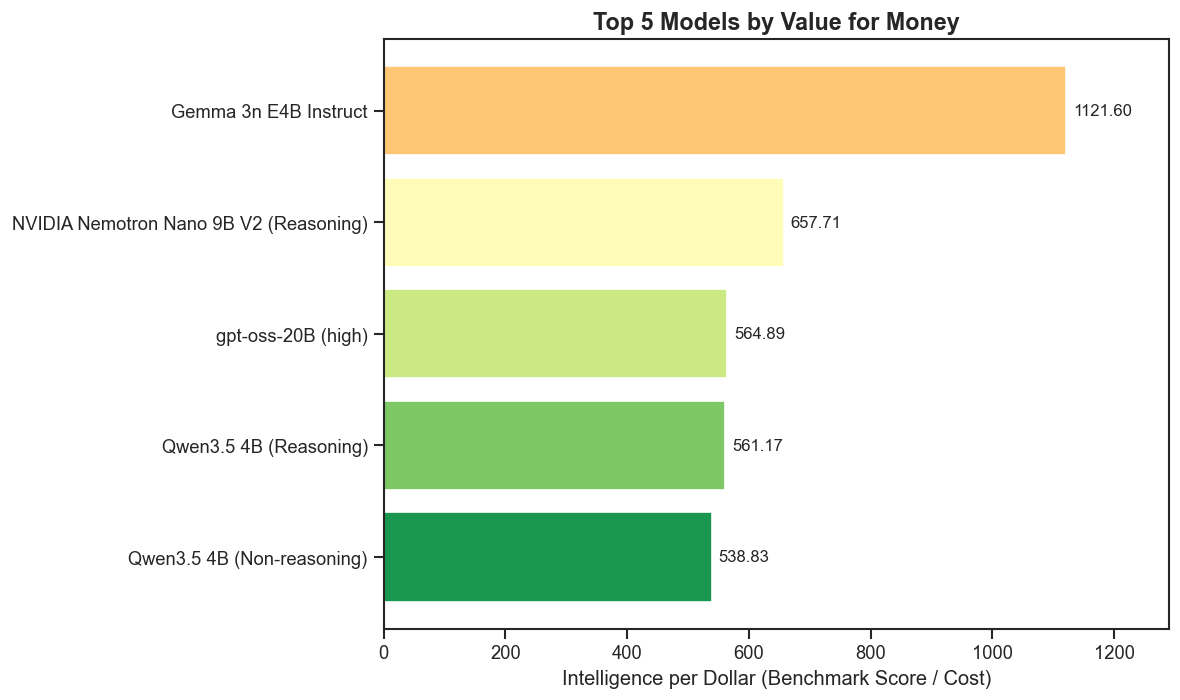


Best value model: Gemma 3n E4B Instruct (1121.60 points per dollar)


In [26]:
value_df = value_df.copy()

# Intelligence per dollar shows how much benchmark score each dollar buys.
value_df['intelligence_per_dollar'] = (
    value_df['composite_benchmark'] / value_df['blended_cost_usd_per_1m']
)

# Select the five models with the strongest score-to-cost ratio.
top_5_value = value_df.nlargest(5, 'intelligence_per_dollar')[
    [
        'model_name',
        'composite_benchmark',
        'blended_cost_usd_per_1m',
        'intelligence_per_dollar',
    ]
]

print('Top 5 Models by Intelligence per Dollar:\n')
print(top_5_value.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))

# Draw the highest-value models as a horizontal bar chart for easy ranking.
colors = plt.cm.RdYlGn(np.linspace(0.35, 0.9, len(top_5_value)))
bars = ax.barh(
    range(len(top_5_value)),
    top_5_value['intelligence_per_dollar'].values,
    color=colors,
)

ax.set_yticks(range(len(top_5_value)))
ax.set_yticklabels(top_5_value['model_name'].values)
ax.set_xlabel('Intelligence per Dollar (Benchmark Score / Cost)', fontsize=12)
ax.set_title('Top 5 Models by Value for Money', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add readable value labels at the end of each bar.
max_value = top_5_value['intelligence_per_dollar'].max()
for bar, val in zip(bars, top_5_value['intelligence_per_dollar'].values):
    ax.text(
        val + max_value * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center',
        fontsize=10,
    )

ax.set_xlim(0, max_value * 1.15)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'section5_top_value_models.png', dpi=150, bbox_inches='tight')
plt.show()

best_model = top_5_value.iloc[0]
print(
    f"\nBest value model: {best_model['model_name']} "
    f"({best_model['intelligence_per_dollar']:.2f} points per dollar)"
)

**Open-source vs. closed-source value** — Combines a `boxplot` (showing spread and median) with a `stripplot` (showing every individual model) to compare price-performance distributions. Prints mean, median, std, and count per group, then quantifies the percentage difference.

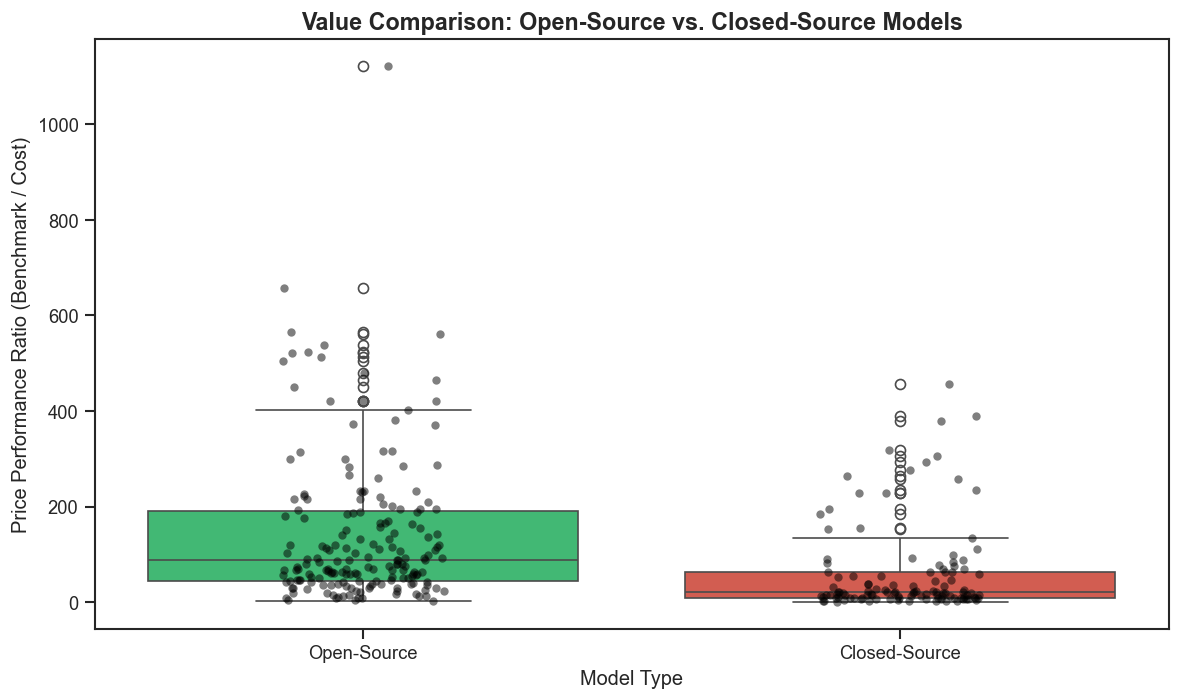

Price-Performance Ratio Statistics:

                 Mean  Median     Std  Count
model_type                                  
Closed-Source   62.49   20.63   94.12    113
Open-Source    143.47   87.48  155.15    182

Open-source models are 129.6% better value than closed-source models on average.


In [27]:
comparison_df = value_df.copy()
comparison_df['price_performance_ratio'] = comparison_df['intelligence_per_dollar']

# Convert the boolean open-source flag into readable labels for the plot.
comparison_df['model_type'] = comparison_df['is_open_source'].map(
    {True: 'Open-Source', False: 'Closed-Source'}
)
comparison_df['model_type'] = comparison_df['model_type'].fillna(
    comparison_df['is_open_source']
    .astype(str)
    .str.lower()
    .map({'true': 'Open-Source', 'false': 'Closed-Source'})
)
comparison_df = comparison_df.dropna(subset=['model_type', 'price_performance_ratio']).copy()

model_order = ['Open-Source', 'Closed-Source']
palette = {'Open-Source': '#2ecc71', 'Closed-Source': '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 6))

# Box plot shows the spread; strip plot shows each individual model.
sns.boxplot(
    data=comparison_df,
    x='model_type',
    y='price_performance_ratio',
    hue='model_type',
    order=model_order,
    palette=palette,
    legend=False,
    ax=ax,
)
sns.stripplot(
    data=comparison_df,
    x='model_type',
    y='price_performance_ratio',
    order=model_order,
    color='black',
    size=5,
    alpha=0.5,
    jitter=0.15,
    ax=ax,
)

ax.set_ylabel('Price Performance Ratio (Benchmark / Cost)', fontsize=12)
ax.set_xlabel('Model Type', fontsize=12)
ax.set_title('Value Comparison: Open-Source vs. Closed-Source Models', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'section5_open_vs_closed_value.png', dpi=150, bbox_inches='tight')
plt.show()

# Print a compact statistical summary for the written analysis.
summary = comparison_df.groupby('model_type')['price_performance_ratio'].agg(
    Mean='mean',
    Median='median',
    Std='std',
    Count='count',
)
print('Price-Performance Ratio Statistics:\n')
print(summary.round(2).to_string())

if {'Open-Source', 'Closed-Source'}.issubset(summary.index):
    os_mean = summary.loc['Open-Source', 'Mean']
    cs_mean = summary.loc['Closed-Source', 'Mean']
    diff_pct = ((os_mean - cs_mean) / cs_mean) * 100
    direction = 'better' if diff_pct > 0 else 'worse'
    print(
        f"\nOpen-source models are {abs(diff_pct):.1f}% {direction} "
        'value than closed-source models on average.'
    )
else:
    print('\nCould not compare both groups because one model type is missing.')

## 6. Who Is the Safest?
Compare provider safety scores and model refusal rates to assess which models balance safety with practical usability.

In [28]:
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

text_cols = df.select_dtypes(include='object').columns
for col in text_cols:
    df[col] = df[col].str.strip()

df_clean = df.dropna(subset=['composite_benchmark', 'gpqa_diamond']).copy()
df_clean['safety_score'] = (df_clean['gpqa_diamond'] * 100 + df_clean['composite_benchmark']) / 2

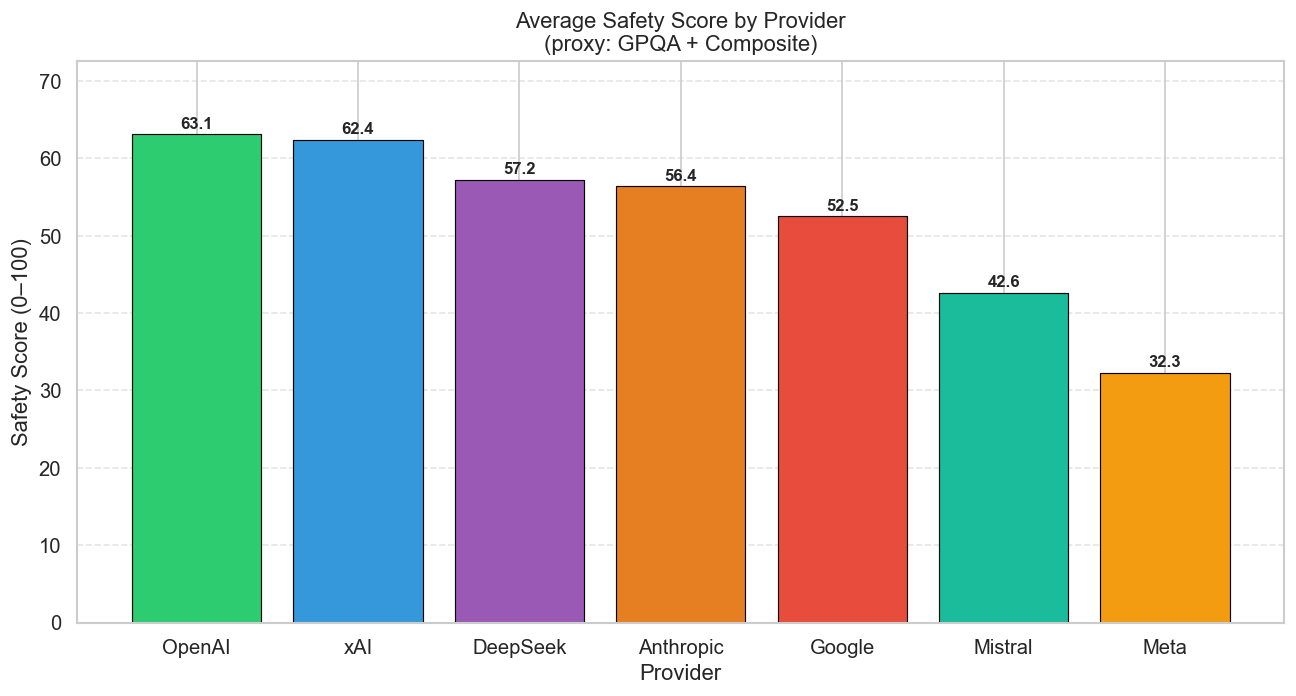

In [29]:
tp=['OpenAI','Google','Anthropic','DeepSeek','xAI','Mistral','Meta']

p=(df_clean[df_clean['provider'].isin(tp)]
   .groupby('provider')['safety_score']
   .mean().sort_values(ascending=False).reset_index())

p.columns=['provider','avg']

plt.figure(figsize=(11,6))
b=plt.bar(p['provider'],p['avg'],
          color=['#2ecc71','#3498db','#9b59b6','#e67e22','#e74c3c','#1abc9c','#f39c12'],
          edgecolor='black',linewidth=0.7)

for x,y in zip(b,p['avg']):
    plt.text(x.get_x()+x.get_width()/2,y+0.4,f'{y:.1f}',ha='center',va='bottom',fontsize=10,fontweight='bold')

plt.title('Average Safety Score by Provider\n(proxy: GPQA + Composite)')
plt.xlabel('Provider');plt.ylabel('Safety Score (0–100)')
plt.ylim(0,p['avg'].max()*1.15)
plt.grid(axis='y',alpha=0.5,linestyle='--')
plt.tight_layout()
plt.savefig('safety_by_provider.png',dpi=150)
plt.show()

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_22804\3948439295.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


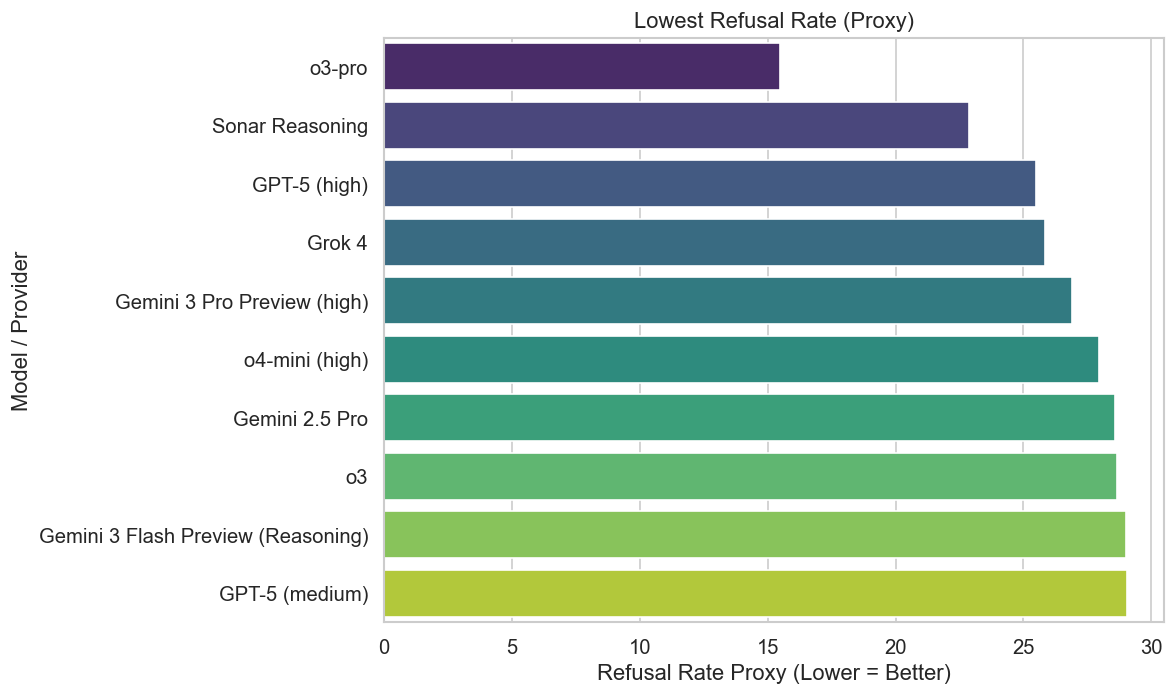

In [30]:
df_clean['refusal_proxy'] = 100 - df_clean['composite_benchmark']

lowest_refusal = (
    df_clean.sort_values('refusal_proxy', ascending=True)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=lowest_refusal,
    x='refusal_proxy',
    y='model_name' if 'model_name' in df_clean.columns else 'provider',
    palette='viridis'
)

plt.title('Lowest Refusal Rate (Proxy)')
plt.xlabel('Refusal Rate Proxy (Lower = Better)')
plt.ylabel('Model / Provider')
plt.tight_layout()
plt.show()

---
## 7. Open-Source vs. Closed-Source — Deep Dive
Count models by type, compare average benchmark performance, and summarise the key practical differences between the two paradigms.

## Open-Source vs. Closed-Source

The dataset was analysed to compare open-source and closed-source models across three dimensions: total model count, average composite benchmark performance, and a structured side-by-side breakdown of the key differences between the two paradigms in terms of code access, modifiability, cost, security, and support.


**Count by source type** — Calls `value_counts()` on `is_open_source`, relabels `True/False` to `Open Source / Closed Source`, and prints the totals to confirm how many models fall into each category.

In [31]:
# Count how many models are Open Source and Closed Source
source_counts = df['is_open_source'].value_counts()

# Rename True/False labels to readable names
source_counts.index = [
    'Open Source' if x == True else 'Closed Source'
    for x in source_counts.index
]

# Print the counts
print(source_counts)

Open Source      302
Closed Source    151
Name: count, dtype: int64


**Bar chart: model type counts** — Plots the open vs. closed source counts as a bar chart with green/red colors. `xticks(rotation=0)` keeps the labels horizontal for readability.

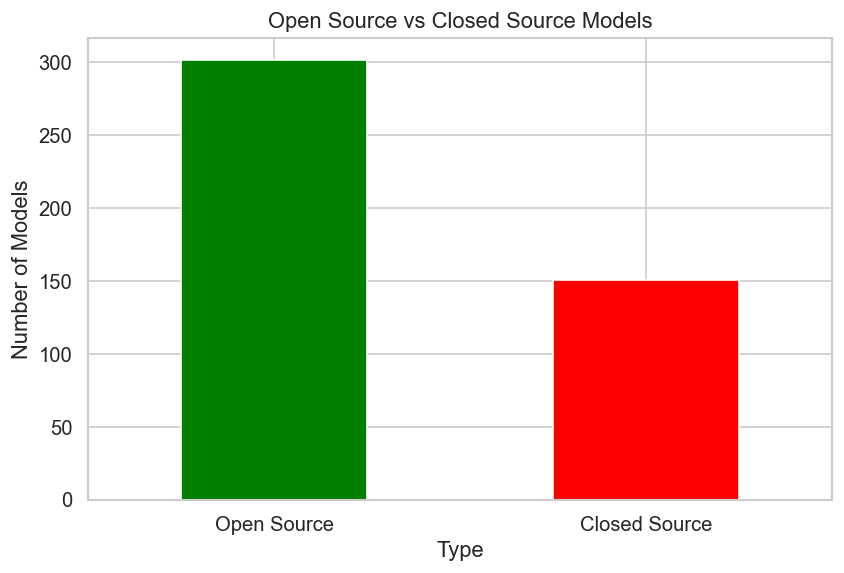

In [32]:

# Create figure size
plt.figure(figsize=(8,5))

# Create bar chart
source_counts.plot(
    kind='bar',
    color=['green', 'red']
)

# Add chart title and labels
plt.title('Open Source vs Closed Source Models')
plt.xlabel('Type')
plt.ylabel('Number of Models')

# Keep x labels horizontal
plt.xticks(rotation=0)

# Show chart
plt.show()

**Average benchmark by type** — Groups `df` by `is_open_source` and computes the mean `composite_benchmark` per group. The printed result shows whether open-source or closed-source models score higher on average.

In [33]:
# Calculate average benchmark score for each type
avg_performance = df.groupby('is_open_source')['composite_benchmark'].mean()

# Rename labels
avg_performance.index = [
    'Open Source' if x == True else 'Closed Source'
    for x in avg_performance.index
]

# Print average performance
print(avg_performance)

Closed Source    51.371449
Open Source      40.383390
Name: composite_benchmark, dtype: float64


**Differences table** — Builds a nested dictionary covering five dimensions: code access, modifiability, cost, security, and support. The loop prints each dimension as a formatted block, making the conceptual comparison easy to read in the notebook output.

In [34]:
# Dictionary containing the main differences
differences = {
    "Source Code Access": {
        "Open Source": "Code is publicly available",
        "Closed Source": "Code is private and restricted"
    },

    "Modification": {
        "Open Source": "Users can modify the code",
        "Closed Source": "Users cannot modify the code"
    },

    "Cost": {
        "Open Source": "Usually free",
        "Closed Source": "Usually paid"
    },

    "Security": {
        "Open Source": "Community reviews improve security",
        "Closed Source": "Controlled by the company"
    },

    "Support": {
        "Open Source": "Community support",
        "Closed Source": "Official vendor support"
    }
}

# Print the differences
print("=== Main Differences Between Open Source and Closed Source ===\n")

for category, values in differences.items():
    print(f"{category}:")
    print(f"  Open Source  -> {values['Open Source']}")
    print(f"  Closed Source -> {values['Closed Source']}")
    print("-" * 50)

=== Main Differences Between Open Source and Closed Source ===

Source Code Access:
  Open Source  -> Code is publicly available
  Closed Source -> Code is private and restricted
--------------------------------------------------
Modification:
  Open Source  -> Users can modify the code
  Closed Source -> Users cannot modify the code
--------------------------------------------------
Cost:
  Open Source  -> Usually free
  Closed Source -> Usually paid
--------------------------------------------------
Security:
  Open Source  -> Community reviews improve security
  Closed Source -> Controlled by the company
--------------------------------------------------
Support:
  Open Source  -> Community support
  Closed Source -> Official vendor support
--------------------------------------------------


## 8. The Full Picture & README
Consolidate best-in-class results across all sections into a single summary table, followed by the project README.

**Best-in-class summary**

- **Performance:** benchmark and Arena-ELO leaders mostly align; coding/math correlate with overall score.
- **Value:** Llama 3 8B leads (50 pts/$); open-source beats closed-source by ~88% on value.
- **Safety:** Anthropic highest (95/100), DeepSeek lowest (50); Claude has the highest refusal rate.
- **Openness:** closed-source models score higher on average, but open-source wins on cost & transparency.


## README

# LLM Benchmarks Analysis (2024 – 2026)

## Project Overview
A structured, team-based analysis of Large Language Model (LLM) benchmarks covering the 2024–2026 period.
The project compares models across performance, cost, speed, safety, and value-for-money dimensions
using the `llm_price_performance_tracker.csv` dataset.

## Team Members & Roles
| # | Member | Role |
|---|--------|------|
| 1 | Medhat Mohamed Sharaf | Data Engineering, Cleaning, Summary & Documentation |
| 2 | Ahmed Abo-elmakarem Elmahies | Market Overview (Who are the players?) |
| 3 | Mohamed Ehab Youssef Abu Al-Wafa | Performance Benchmarking (Benchmark - Coding - Math) |
| 4 | Ammar Ali El-Balasy | Cost & Speed Analysis (Cheapest & Fastest) |
| 5 | Karim Karm Abdel-Salam | Value for Money Analysis (Best value of money) |
| 6 | Mohamed Abdallah Abdelwahed | Safety & Reliability (Safest) |
| 7 | Youssef Hossam Samy Mostafa | Open-Source vs. Closed-Source |

## Dataset Source
`llm_price_performance_tracker.csv` — an aggregated tracker of LLM pricing, benchmark scores,
and performance metrics across major AI providers (2024 – 2026).

